In [1]:
import sys
import os

sys.path.append(os.path.abspath('..')) 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


In [3]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
from src.modeling.model import (
    scale_features,
    split_by_engines,
    get_xy
)

%load_ext autoreload
%autoreload 2

In [5]:
#load and prep data
df_train_features = pd.read_csv("../data/processed/train_features.csv")
df_test_features = pd.read_csv("../data/processed/test_features.csv")
print(df_train_features.shape, df_test_features.shape)



(20331, 94) (12796, 93)


In [6]:
#scale fit on train only
df_train_scaled, scaler = scale_features(df_train_features, is_fit=True)
df_test_scaled, _ = scale_features(df_test_features, scaler=scaler, is_fit=False)


In [7]:
# split by engine
df_train_split, df_val_split = split_by_engines(df_train_scaled, train_engines=70, val_engines=15)
X_train, y_train = get_xy(df_train_split)
X_val, y_val = get_xy(df_val_split)

print(X_train.shape, X_val.shape)

train: 13920 rows, val: 3165 rows
(13920, 91) (3165, 91)


In [8]:
# test set last cycle per engine
df_test_last = df_test_scaled.groupby('engine_number').last().reset_index()
X_test_last, _ = get_xy(df_test_last)
rul_test = pd.read_csv("../data/raw/RUL_FD001.txt", header=None, names=['true_RUL'])

print(X_test_last.shape, rul_test.shape)

(100, 91) (100, 1)


In [9]:
# baseline - linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

lr_rmse = np.sqrt(mean_squared_error(y_val, y_pred_lr))
lr_mae = mean_absolute_error(y_val, y_pred_lr)
lr_r2 = r2_score(y_val, y_pred_lr)

print(f"LR - RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}, R2: {lr_r2:.4f}")

LR - RMSE: 21.43, MAE: 17.80, R2: 0.7560


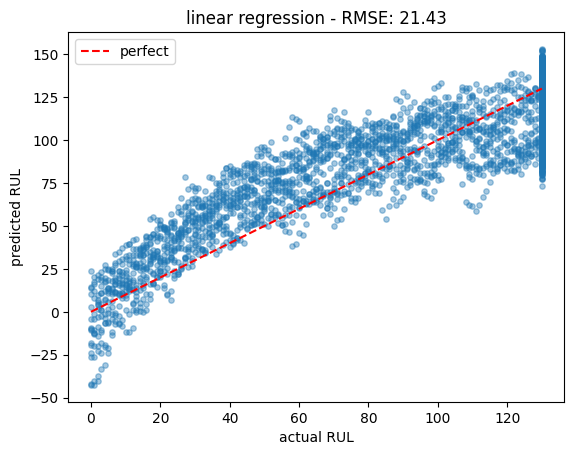

In [10]:
plt.scatter(y_val, y_pred_lr, alpha=0.4, s=15)
plt.plot([0, 130], [0, 130], 'r--', label='perfect')
plt.xlabel('actual RUL')
plt.ylabel('predicted RUL')
plt.title(f'linear regression - RMSE: {lr_rmse:.2f}')
plt.legend()
plt.show()

In [11]:
#predictions go negative for low RUL which is alinear regression limitation
#let's try ridge next

In [12]:
#maybe regularization helps
#tuning alpha
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print(f"alpha={alpha}: RMSE={rmse:.2f}")

alpha=0.001: RMSE=21.43
alpha=0.01: RMSE=21.43
alpha=0.1: RMSE=21.43
alpha=1.0: RMSE=21.43
alpha=10.0: RMSE=21.43
alpha=100.0: RMSE=21.52


In [13]:
#alpha doesn't make much difference here, all give ~21.43
#ridge not really better than linear regression
#random forest should do better
ridge_model = Ridge(alpha=1.0)  #justgonna use default
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_val)

ridge_rmse = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
ridge_mae = mean_absolute_error(y_val, y_pred_ridge)
ridge_r2 = r2_score(y_val, y_pred_ridge)

print(f"Ridge - RMSE: {ridge_rmse:.2f}, MAE: {ridge_mae:.2f}, R2: {ridge_r2:.4f}")

Ridge - RMSE: 21.43, MAE: 17.80, R2: 0.7560


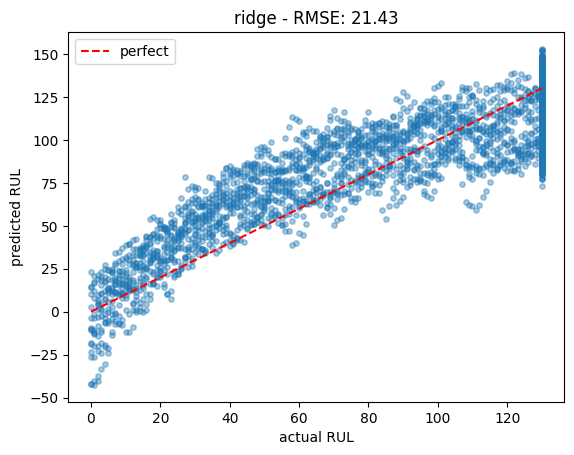

In [14]:
plt.scatter(y_val, y_pred_ridge, alpha=0.4, s=15)
plt.plot([0, 130], [0, 130], 'r--', label='perfect')
plt.title(f'ridge - RMSE: {ridge_rmse:.2f}')
plt.xlabel('actual RUL')
plt.ylabel('predicted RUL')
plt.legend()
plt.show()

In [15]:
# random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
print(f"RF default - RMSE: {rf_rmse:.2f}")

RF default - RMSE: 19.21


In [16]:
# trying different number of trees
for n_est in [100, 200, 300]:
    rf = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_val, rf.predict(X_val)))
    print(f"n_estimators={n_est}: RMSE={rmse:.2f}")

n_estimators=100: RMSE=19.21
n_estimators=200: RMSE=19.15
n_estimators=300: RMSE=19.14


In [17]:
# try different depths
for depth in [10, 20, None]:
    rf = RandomForestRegressor(n_estimators=300, max_depth=depth, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_val, rf.predict(X_val)))
    print(f"max_depth={depth}: RMSE={rmse:.2f}")

max_depth=10: RMSE=18.82
max_depth=20: RMSE=19.14
max_depth=None: RMSE=19.14


In [18]:
# best params from tuning
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
rf_mae = mean_absolute_error(y_val, y_pred_rf)
rf_r2 = r2_score(y_val, y_pred_rf)

print(f"RF final - RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}, R2: {rf_r2:.4f}")

RF final - RMSE: 18.82, MAE: 13.93, R2: 0.8118


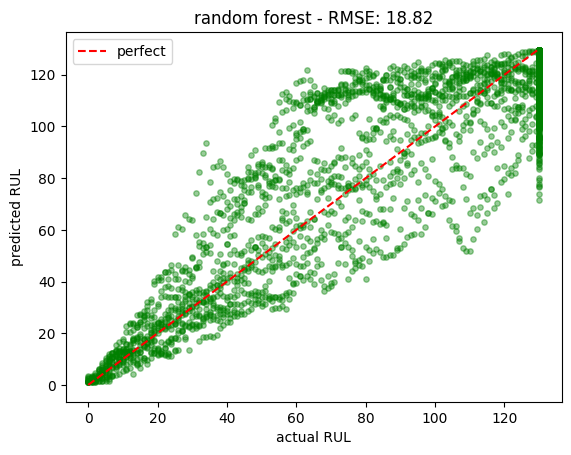

In [19]:
plt.scatter(y_val, y_pred_rf, alpha=0.4, s=15, color='green')
plt.plot([0, 130], [0, 130], 'r--', label='perfect')
plt.title(f'random forest - RMSE: {rf_rmse:.2f}')
plt.xlabel('actual RUL')
plt.ylabel('predicted RUL')
plt.legend()
plt.show()


In [20]:
# compare all models
results = {
    'linear regression': {'rmse': lr_rmse, 'mae': lr_mae, 'r2': lr_r2},
    'ridge': {'rmse': ridge_rmse, 'mae': ridge_mae, 'r2': ridge_r2},
    'random forest': {'rmse': rf_rmse, 'mae': rf_mae, 'r2': rf_r2}
}

pd.DataFrame(results).T

,rmse,mae,r2
linear regression,21.432826,17.797482,0.755963
ridge,21.431648,17.796978,0.755990
random forest,18.820475,13.927133,0.811827


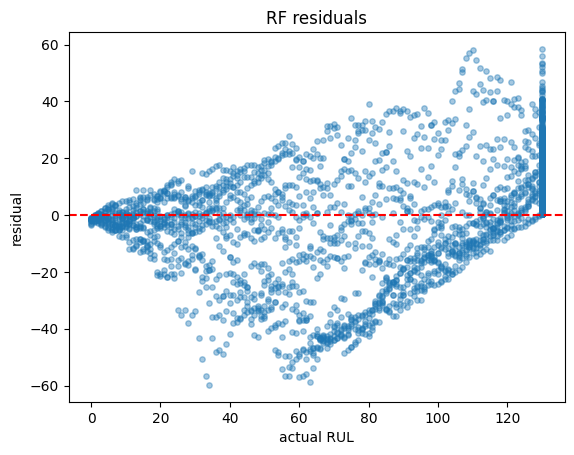

In [22]:
# residual plot for random forest
residuals = y_val - y_pred_rf
plt.scatter(y_val, residuals, alpha=0.4, s=15)
plt.axhline(0, color='red', linestyle='--')
plt.title('RF residuals')
plt.xlabel('actual RUL')
plt.ylabel('residual')
plt.show()
# mostly random scatter around 0

In [23]:
# which features matter most?
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importances.head(15)

,feature,importance
35,sensor_4_mean_10,0.362849
33,sensor_3_mean_10,0.158084
5,sensor_4_mean_5,0.118076
43,sensor_9_mean_10,0.052517
13,sensor_9_mean_5,0.052284
59,sensor_21_mean_10,0.041773
31,sensor_2_mean_10,0.037729
15,sensor_11_mean_5,0.031398
53,sensor_15_mean_10,0.017687
51,sensor_14_mean_10,0.011333


In [24]:
# evaluate on actual test set
rul_test = pd.read_csv("../data/raw/RUL_FD001.txt", header=None, names=['true_RUL'])

df_test_last = df_test_scaled.groupby('engine_number').tail(1).reset_index(drop=True)
X_test_last = df_test_last[[col for col in df_test_last.columns 
                            if col not in ['engine_number', 'cycle']]]

y_pred_test = rf_model.predict(X_test_last)

test_rmse = np.sqrt(mean_squared_error(rul_test['true_RUL'], y_pred_test))
test_mae = mean_absolute_error(rul_test['true_RUL'], y_pred_test)
test_r2 = r2_score(rul_test['true_RUL'], y_pred_test)

print(f"Test - RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}, R2: {test_r2:.4f}")
print(f"Val RMSE was {rf_rmse:.2f}, test is {test_rmse:.2f}")

Test - RMSE: 19.70, MAE: 14.07, R2: 0.7752
Val RMSE was 18.82, test is 19.70


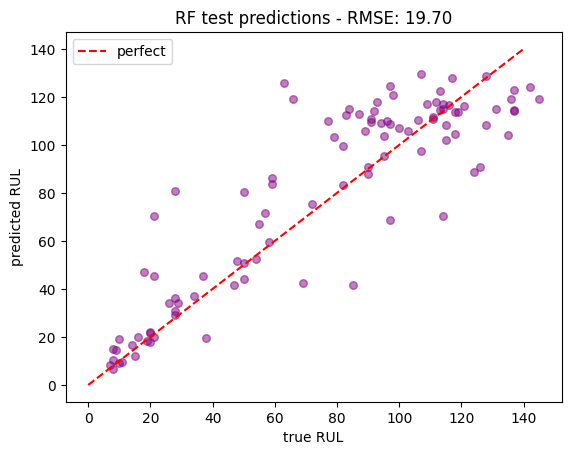

In [25]:
plt.scatter(rul_test['true_RUL'], y_pred_test, alpha=0.5, s=30, color='purple')
plt.plot([0, 140], [0, 140], 'r--', label='perfect')
plt.title(f'RF test predictions - RMSE: {test_rmse:.2f}')
plt.xlabel('true RUL')
plt.ylabel('predicted RUL')
plt.legend()
plt.show()

In [26]:
# save the model
joblib.dump(rf_model, "../models/rf_model.pkl")
print("saved rf_model.pkl")

saved rf_model.pkl


In [27]:
# test all models
for name, model in [('LR', lr_model), ('Ridge', ridge_model), ('RF', rf_model)]:
    pred = model.predict(X_test_last)
    rmse = np.sqrt(mean_squared_error(rul_test['true_RUL'], pred))
    print(f"{name}: RMSE={rmse:.2f}")

LR: RMSE=21.93
Ridge: RMSE=21.93
RF: RMSE=19.70


In [28]:
# nasa scoring function 
def nasa_score(y_true, y_pred):
    diff = y_true - y_pred
    return np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))

print(f"NASA score (RF): {nasa_score(rul_test['true_RUL'], y_pred_test):.0f}")

NASA score (RF): 765


In [29]:
results = {
    'Model': ['Linear Regression', 'Ridge', 'Random Forest'],
    'Val RMSE': [21.43, 21.43, 18.82],
    'Test RMSE': [21.93, 21.92, 19.70],
}
pd.DataFrame(results)

,Model,Val RMSE,Test RMSE
0,Linear Regression,21.43,21.93
1,Ridge,21.43,21.92
2,Random Forest,18.82,19.70


## notes

- linear regression baseline: RMSE 21.43
- ridge didn't help, same as LR
- random forest: RMSE 18.82 on val, 19.70 on test
- sensor_4_mean_10 most important feature
- model saved to models/rf_model.pkl

In [31]:
import pandas as pd

for label in ['healthy', 'warning', 'critical']:
    df = pd.read_csv(f"../data/demo/{label}_engine.csv")
    print(f"{label}: {len(df)} rows, engine_number: {df['engine_number'].unique()}")

healthy: 155 rows, engine_number: [28]
critical: 86 rows, engine_number: [95]


In [32]:
rul_test = pd.read_csv("../data/raw/RUL_FD001.txt", header=None, names=['true_RUL'])

print("engine 28 (healthy) true RUL:", rul_test.iloc[27]['true_RUL'])
print("engine 72 (warning) true RUL:", rul_test.iloc[71]['true_RUL'])
print("engine 95 (critical) true RUL:", rul_test.iloc[94]['true_RUL'])

engine 28 (healthy) true RUL: 97
engine 72 (warning) true RUL: 50
engine 95 (critical) true RUL: 128


In [33]:
# find engines with low RUL (critical), medium (warning), high (healthy)
print("Critical engines (RUL < 20):")
print(rul_test[rul_test['true_RUL'] < 20].head(10))

print("\nWarning engines (RUL 30-60):")
print(rul_test[(rul_test['true_RUL'] >= 30) & (rul_test['true_RUL'] <= 60)].head(10))

print("\nHealthy engines (RUL > 100):")
print(rul_test[rul_test['true_RUL'] > 100].head(10))

Critical engines (RUL < 20):
    true_RUL
19        16
30         8
33         7
34        11
35        19
40        18
41        10
55        15
65        14
67         8

Warning engines (RUL 30-60):
    true_RUL
16        50
20        57
31        48
37        50
42        59
45        47
57        37
61        54
71        50
76        34

Healthy engines (RUL > 100):
    true_RUL
0        112
8        111
11       124
13       107
21       111
22       113
24       145
25       119
29       115
32       106


In [34]:
demo_engines = {'healthy': 25, 'warning': 17, 'critical': 34}

for label, engine_id in demo_engines.items():
    df_engine = df_test_features[df_test_features['engine_number'] == engine_id]
    df_engine.to_csv(f"../data/demo/{label}_engine.csv", index=False)
    print(f"saved {label}_engine.csv - {len(df_engine)} rows")

saved healthy_engine.csv - 45 rows
saved warning_engine.csv - 162 rows
saved critical_engine.csv - 200 rows
